# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [71]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [72]:
# Load raw candidate response data from alldata.xlsx
raw_data = pd.read_excel('alldata.xlsx')

# Display the first few rows for inspection
display(raw_data.head())

# Define party colors for consistent plotting
party_colors = {
    "Socialdemokratiet": "#b32722",
    "Radikale Venstre": "#713280",
    "Det Konservative Folkeparti": "#9eba27",
    "Nye Borgerlige": "#054f5c",
    "Socialistisk Folkeparti": "#dd0878",
    "Liberal Alliance": "#21c6cf",
    "Kristendemokraterne": "#bababa",
    "Moderaterne": "#6c39e5",
    "Dansk Folkeparti": "#f3cd41",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#00e66a",
    "Venstre": "#006697",
    "Danmarksdemokraterne": "#8ac3ff",
    "Enhedslisten": "#ed8019",
    "Alternativet": "#2a8f39",
    "Løsgænger": "#8c564b"
}

# Define question columns and readable labels for plotting
question_columns = [
    '1a', '1b', '530', '546', '559', '561', '7a', '7b', '4a', '4b',
    '531', '541', '545', '550', '556', '8a', '8b', '9a', '9b', '538',
    '553', '5a', '5b', '537', '540', '543', '548', '557', '2a', '2b',
    '552', '563', '544', '547', '533', '534', '535', '551', '555',
    '3a', '3b', '6a', '6b', '10a', '10b', '11a', '11b', '12a', '12b'
]

question_labels = [
    '1a [Miljø/Klima]', '1b [Miljø/Klima]', '530 [Miljø/Klima]', '546 [Klima/Energi]', '559 [Klima/Energi]', '561 [Klima/Energi]',
    '7a [Energi]', '7b [Energi]', '4a [Økonomi]', '4b [Økonomi]', '531 [Arbejdsmarked/Økonomi]', '541 [Arbejdsmarked/Økonomi]',
    '545 [Arbejdsmarked/Økonomi]', '550 [Arbejdsmarked/Økonomi]', '556 [Arbejdsmarked/Økonomi]', '8a [Børn/Unge]', '8b [Børn/Unge]',
    '9a [Skole/Uddannelse]', '9b [Skole/Uddannelse]', '538 [Uddannelse]', '553 [Uddannelse]', '5a [Ældre]', '5b [Ældre]',
    '537 [Velfærd]', '540 [Velfærd]', '543 [Velfærd]', '548 [Velfærd]', '557 [Velfærd]', '2a [Hospice/Sundhed]', '2b [Hospice/Sundhed]',
    '552 [Sundhed]', '563 [Sundhed]', '544 [Demokrati]', '547 [Demokrati]', '533 [Ret/Straf]', '534 [EU/Udenrigs]', '535 [EU/Udenrigs]',
    '551 [EU/Udenrigs]', '555 [EU/Udenrigs]', '3a [Udenrigs/Forsvarspolitik]', '3b [Udenrigs/Forsvarspolitik]',
    '6a [Flygtninge/Indvandring]', '6b [Flygtninge/Indvandring]', '10a [Social]', '10b [Social]', '11a [Mink-Sagen]',
    '11b [Mink-Sagen]', '12a [Coronavirus]', '12b [Coronavirus]'
]

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


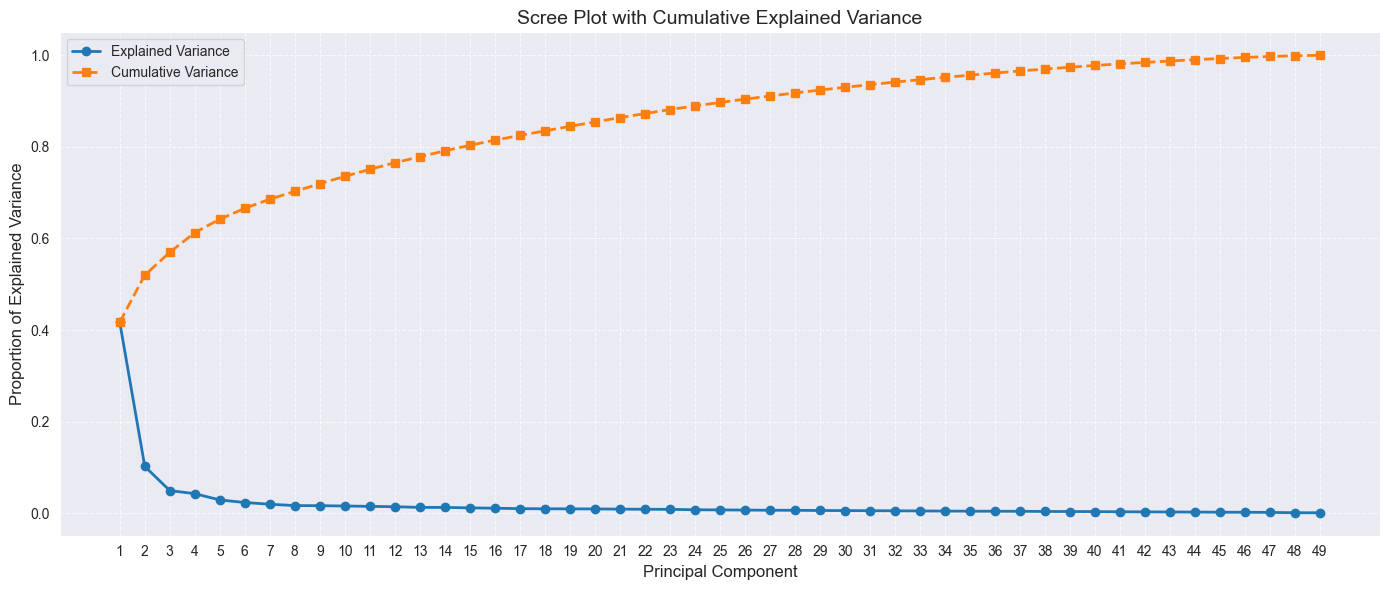

In [73]:
# PCA Analysis to Identify Influential Questions in Ideological Space

# Methodology Introduction:
# Principal Component Analysis (PCA) is used here to reduce dimensionality and understand 
# which questions contribute most to variation in candidate responses.
# Each principal component (PC) is a new axis that captures a percentage of the total variance.
# By analyzing how much variance each PC explains, and which questions load most heavily onto each component,
# we can infer which issues are most ideologically divisive.

# --------------------------------------------

# Step 1: Copy the raw dataset
data = raw_data.copy()

# Step 2: Remove non-numeric metadata columns
# These are identifiers and demographic info that aren't part of the response data.
X_PCA = data.drop(columns=['storkreds', 'alder', 'navn', 'parti'], errors='ignore')

# Step 3: Drop rows with missing data (to ensure PCA runs smoothly)
X_PCA = X_PCA.dropna()

# Step 4: Standardize the data
# This centers each feature (question) at 0 and scales it to unit variance,
# so that all questions are treated equally regardless of their original scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_PCA)

# Step 5: Perform PCA keeping all components
# This lets us analyze the explained variance of each individual component.
pca = PCA(n_components=None)
pca.fit(X_scaled)

# Step 6: Retrieve explained variance per component
explained_var = pca.explained_variance_ratio_           # How much variance each PC explains
cumulative_var = np.cumsum(explained_var)               # Cumulative total of explained variance

# Step 7: Plot the scree plot to visualize variance explained

plt.figure(figsize=(14, 6))

# Line plot for individual component variance
plt.plot(range(1, len(explained_var) + 1), explained_var, 
         marker='o', linewidth=2, label='Explained Variance')

# Line plot for cumulative variance
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 
         marker='s', linestyle='--', linewidth=2, label='Cumulative Variance')

# Labeling and grid
plt.title('Scree Plot with Cumulative Explained Variance', fontsize=14)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Proportion of Explained Variance', fontsize=12)
plt.xticks(np.arange(1, len(explained_var) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [74]:
# Based on the plot above, we can see that the elbow point is about 3-5 components. Keeping 5 components lets us capture about 64% of the data's information

# Redo the PCA, using 5 components
pca = PCA(n_components=5)
pca.fit(X_scaled)

# List the most important features in order of importance
print("\nTop questions for each principal component")

# Loop through the components
for i, component in enumerate(pca.components_):
    print(f"PCA {i+1}:")

    # Match the component weights to feature names and labels
    feature_weights = pd.Series(component, index=question_labels)

    # Sort by absolute value (importance), descending
    sorted_features = feature_weights.abs().sort_values(ascending=False)

    # Print top 2 questions for this principal component
    for idx in sorted_features.head(2).index:
        value = feature_weights[idx]
        print(f" - {idx} (weight: {value:.3f})")
    print()


Top questions for each principal component
PCA 1:
 - 1a [Miljø/Klima] (weight: 0.191)
 - 561 [Klima/Energi] (weight: -0.190)

PCA 2:
 - 10b [Social] (weight: 0.303)
 - 553 [Uddannelse] (weight: -0.298)

PCA 3:
 - 546 [Klima/Energi] (weight: 0.406)
 - 550 [Arbejdsmarked/Økonomi] (weight: -0.340)

PCA 4:
 - 533 [Ret/Straf] (weight: 0.409)
 - 3a [Udenrigs/Forsvarspolitik] (weight: 0.391)

PCA 5:
 - 550 [Arbejdsmarked/Økonomi] (weight: 0.433)
 - 537 [Velfærd] (weight: -0.291)



In [84]:
# PCA Component Interpretation: Identifying Key Influential Questions

# Context:
# After identifying that 3–5 components explain most of the variance (about 64%),
# we re-run PCA with 5 components to explore which individual questions contribute most to each ideological axis.

# Step 1: Run PCA with 5 components

pca = PCA(n_components=5)
pca.fit(X_scaled)

# Step 2: Interpret the components
# Each component is a direction (axis) in the transformed space.
# The weight (loading) of each question shows how much it contributes to that component.

print("\n🔎 Top contributing questions to each principal component:")

# Loop through each principal component
for i, component in enumerate(pca.components_):
    print(f"\nPCA {i+1} (Explains {pca.explained_variance_ratio_[i]*100:.1f}% of variance):")

    # Create a mapping of question weights using their labels
    feature_weights = pd.Series(component, index=question_labels)

    # Sort by the absolute value of the weights (strongest influence, regardless of direction)
    sorted_features = feature_weights.abs().sort_values(ascending=False)

    # Display the top 2 most influential questions
    for idx in sorted_features.head(2).index:
        weight = feature_weights[idx]
        print(f" - {idx} (weight: {weight:.3f})")


🔎 Top contributing questions to each principal component:

PCA 1 (Explains 41.7% of variance):
 - 1a [Miljø/Klima] (weight: 0.191)
 - 561 [Klima/Energi] (weight: -0.190)

PCA 2 (Explains 10.3% of variance):
 - 10b [Social] (weight: 0.303)
 - 553 [Uddannelse] (weight: -0.298)

PCA 3 (Explains 5.0% of variance):
 - 546 [Klima/Energi] (weight: 0.406)
 - 550 [Arbejdsmarked/Økonomi] (weight: -0.340)

PCA 4 (Explains 4.3% of variance):
 - 533 [Ret/Straf] (weight: 0.409)
 - 3a [Udenrigs/Forsvarspolitik] (weight: 0.391)

PCA 5 (Explains 2.9% of variance):
 - 550 [Arbejdsmarked/Økonomi] (weight: 0.433)
 - 537 [Velfærd] (weight: -0.291)


Conclusion:
Based on the PCA analysis, we can identify which questions contribute most to the variation in candidate responses — many of which reflect interparty differences. This insight helps prioritize the most informative questions for model training, potentially improving efficiency by focusing on features that carry the most explanatory power.

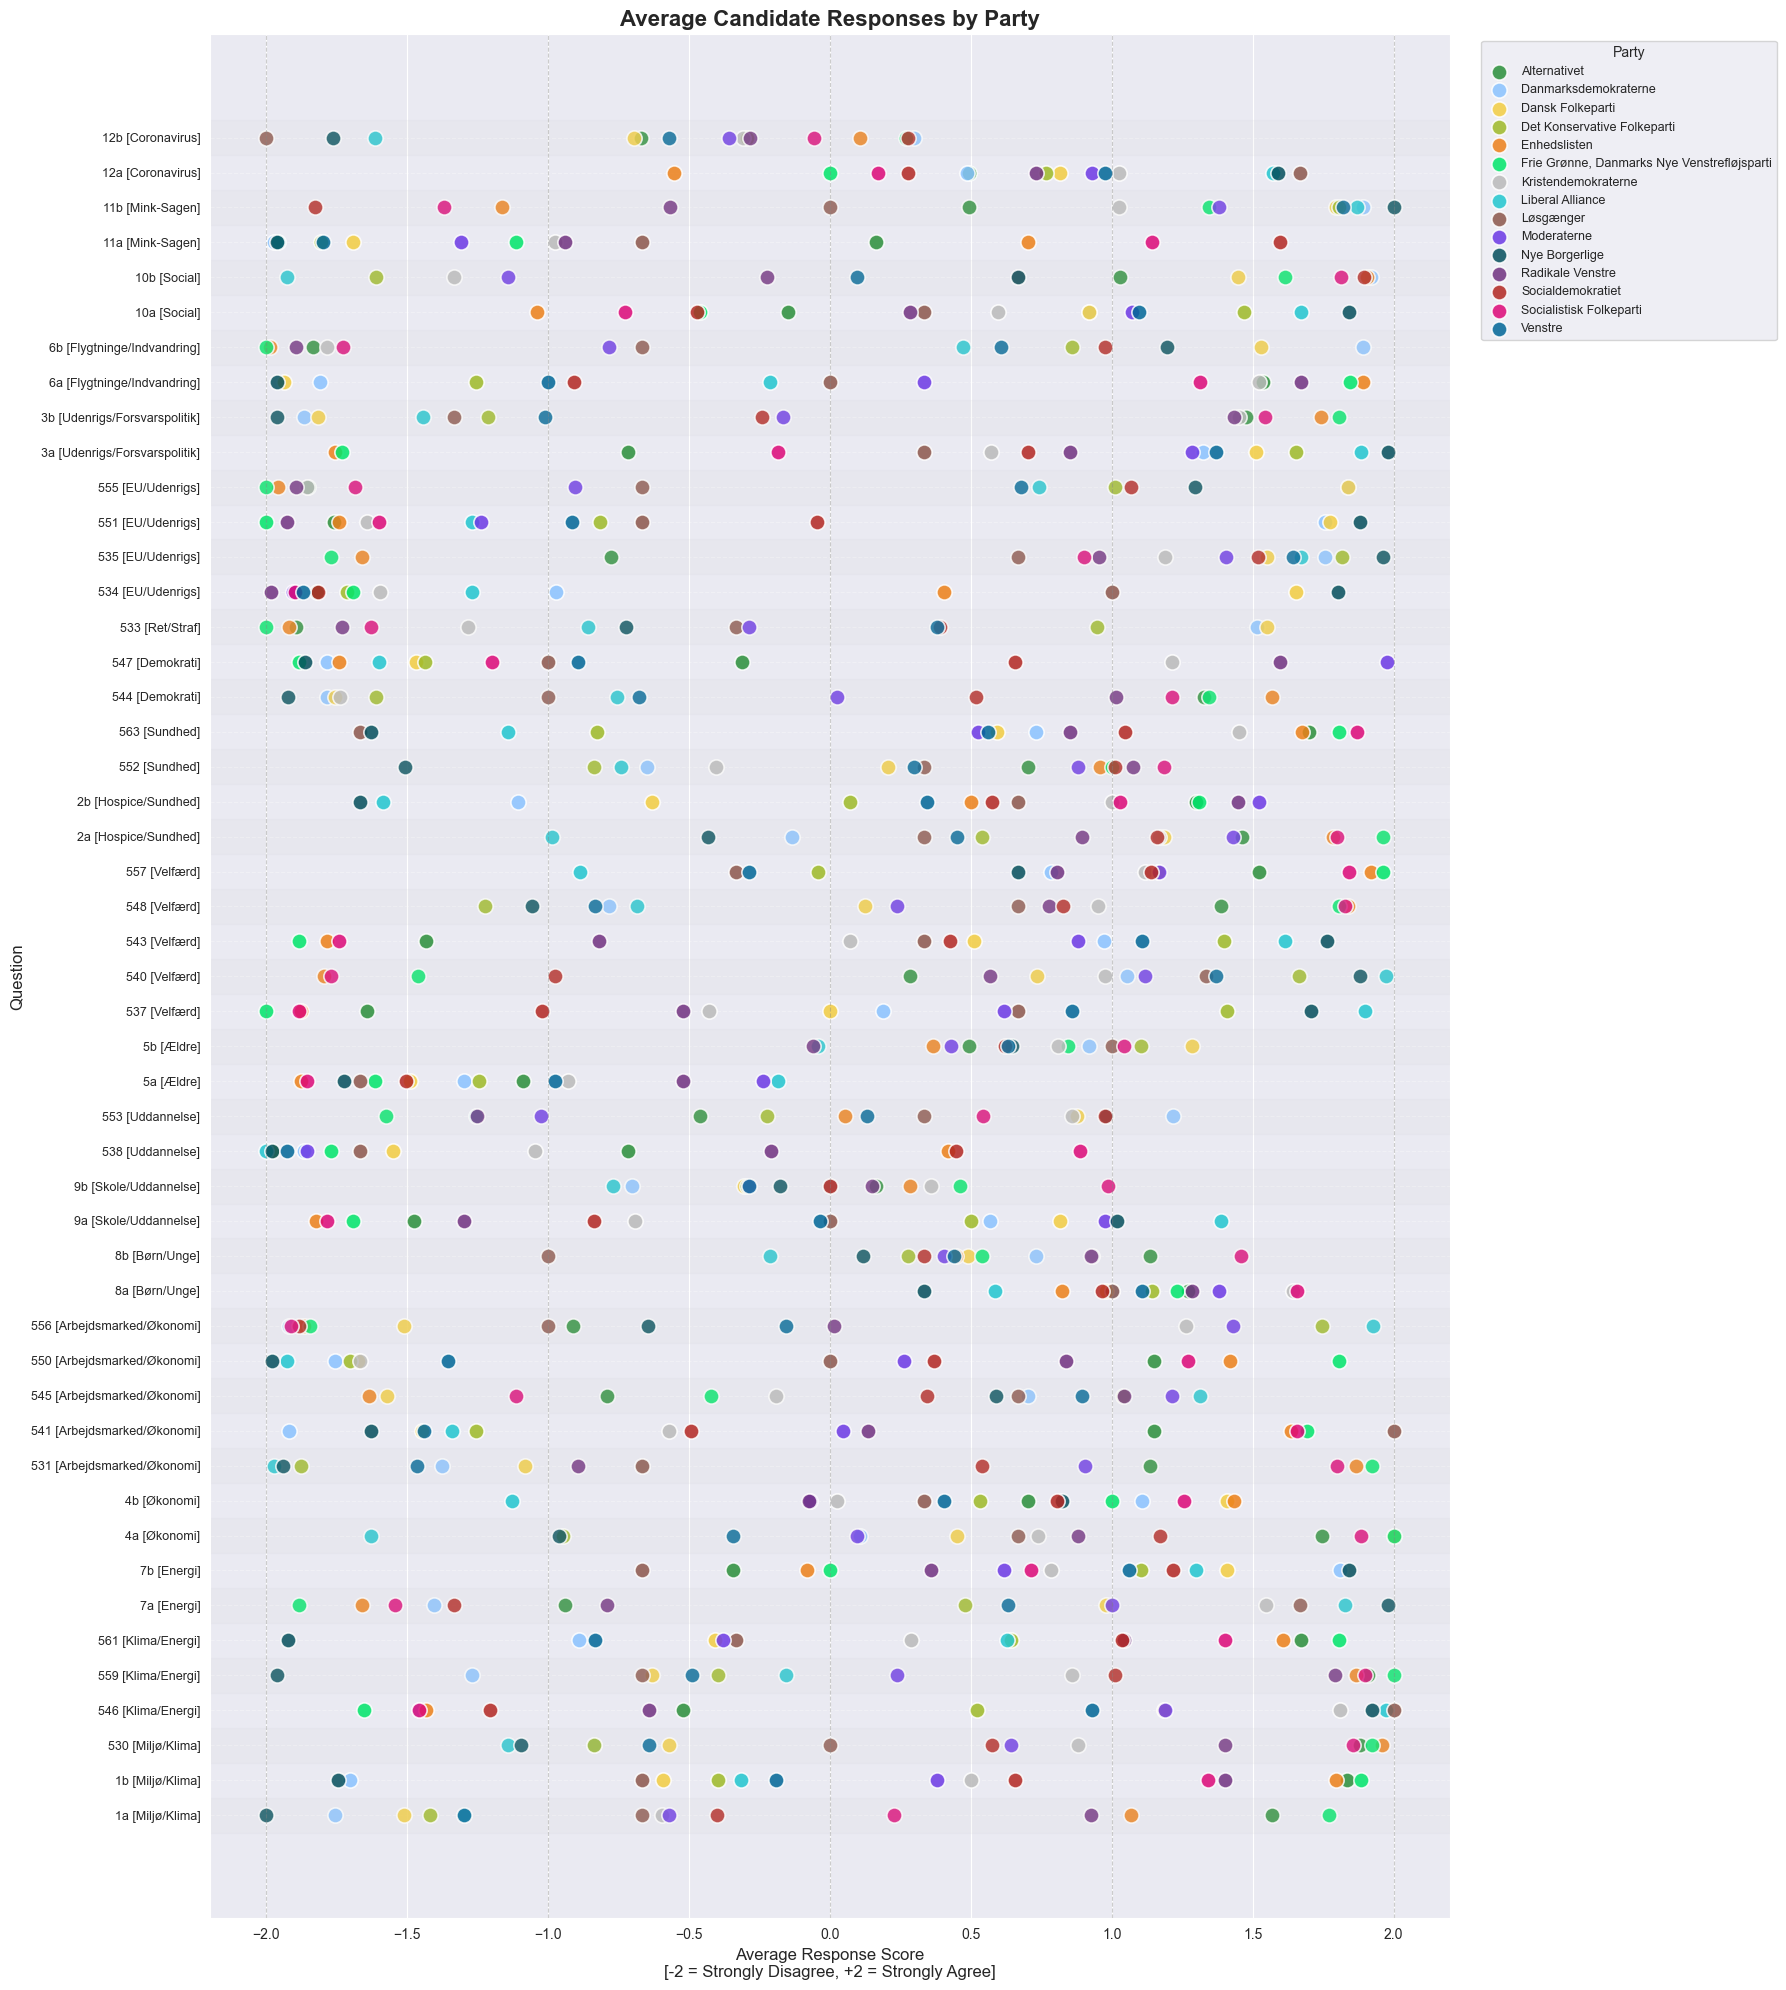

In [85]:
# Average Party Positions on Each Question

# Objective:
# To understand where political parties stand on individual questions,
# we compute and visualize the average response of each party per question.
# This gives a clear overview of ideological positioning across the survey.

# Step 1: Prepare the data
# Remove non-response columns (like region, age, name)
task2data = raw_data.drop(columns=['storkreds', 'alder', 'navn'], errors='ignore')

# Step 2: Compute average responses for each question by party
# Transpose the result so each row is a question, and columns represent parties
mean_party_responses = task2data.groupby('parti')[question_columns].mean().T

# Step 3: Create a scatter plot of average responses per party per question
fig, ax = plt.subplots(figsize=(18, 20))
y_positions = np.arange(len(mean_party_responses.index))  # One y-position per question

# Plot one point per party per question
for party in mean_party_responses.columns:
    color = party_colors.get(party, "#7f7f7f")  # Default to grey if color not found
    ax.scatter(mean_party_responses[party], y_positions, label=party,
               color=color, s=120, edgecolor='white', alpha=0.85, linewidth=1.2)

#  Configure y-axis with question labels
ax.set_yticks(y_positions)
ax.set_yticklabels(question_labels, fontsize=9)

# Label axes and title
ax.set_xlabel("Average Response Score\n[-2 = Strongly Disagree, +2 = Strongly Agree]", fontsize=12)
ax.set_ylabel("Question", fontsize=12)
ax.set_title("Average Candidate Responses by Party", fontsize=16, weight='bold')

# Add alternating background shading for better readability
for i in range(0, len(y_positions), 2):
    ax.axhspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.1)

# Add reference lines for neutral and extreme responses
for x in range(-2, 3):
    ax.axvline(x=x, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

#  Final plot formatting
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [77]:
## A clustering analysis where you attempt various cluster numbers, which would correspond to different parties.
## Discuss whether there is room for more clusters/parties or if a reduction is needed.
## This analysis covers: K-Means, Hierarchical clustering, and DBSCAN

## PCA reduction is not used for clustering, as we want to preserve all question features for accurate grouping.
## PCA is only used here for 2D visualization, since plotting 50+ dimensions isn't practical.

# 1. Data Preparation:
## Drop non-numeric metadata columns ('storkreds', 'alder', 'navn', 'parti')
x = raw_data
x = x.drop(columns=['storkreds', 'alder', 'navn', 'parti'])

## Drop rows with any missing responses
x = x.dropna()

# 2. Standardize the features
## Scale all features to have mean = 0 and standard deviation = 1 to ensure fair clustering
scaler = StandardScaler()
x_Scaled = scaler.fit_transform(x)

# 3. PCA for 2D Visualization only
## We reduce the data to 2 principal components for visual interpretation of clustering results
pca_visualization = PCA(n_components=2)
x_visualization = pca_visualization.fit_transform(x_Scaled)

# 4. Define plotting function for 2D PCA scatterplot
## Colors represent different cluster assignments
def plotCluster(fitted_data, graph_name):
  plt.scatter(x_visualization[:, 0], x_visualization[:, 1], c=fitted_data, cmap='rainbow', s=10)
  plt.title(graph_name)
  plt.xlabel('PC1')
  plt.ylabel('PC2')
  plt.grid(True)
  plt.show()


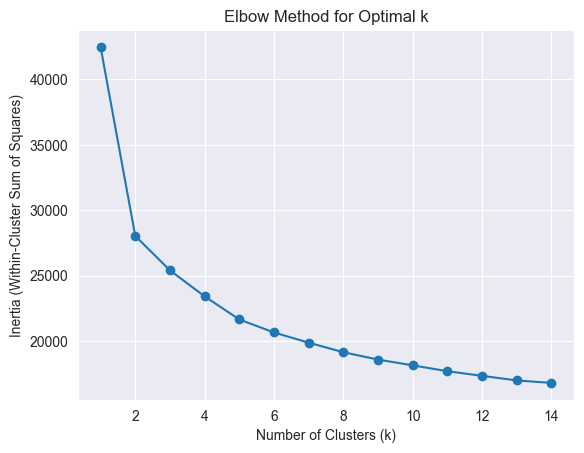

In [78]:
## K-Means Clustering
# We apply the elbow method to identify the optimal number of clusters (k).

# 💡 Explanation:
# - The K-Means algorithm tries to group similar data points by minimizing the "inertia" (within-cluster sum of squares).
# - We test values of k from 1 to 14 to observe how inertia decreases.
# - The "elbow point" in the plot indicates a good trade-off between low inertia and model simplicity.

costs = []  # List to store inertia values for each k
k_range = range(1, 15)  # Try cluster counts from 1 to 14

for k in k_range:
    # Initialize KMeans with:
    # - k clusters
    # - random_state for reproducibility
    # - 'k-means++' for smarter centroid initialization
    # - 15 restarts to ensure best result
    kmeans = KMeans(n_clusters=k, random_state=761, init='k-means++', n_init=15)
    
    # Fit model and compute cluster assignments
    kmeans.fit_predict(x_Scaled)
    
    # Append the inertia (sum of squared distances to nearest centroid)
    costs.append(kmeans.inertia_)

# Plotting the elbow curve
plt.plot(k_range, costs, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [79]:
# Based on the elbow plot above, the optimal number of clusters appears to be around 5.
# Interpretation:
# - This suggests that, based on candidates' responses, the data naturally groups into ~5 distinct ideological clusters.
# - Since there are more than 5 actual parties, this implies some parties are closely aligned in policy space.

# Step: Run final K-Means clustering with k = 5 (based on elbow method)
kmeans = KMeans(
    random_state=761,     # Set random seed for reproducibility
    n_clusters=5,         # Use 5 clusters as estimated optimal
    n_init=15,            # Run algorithm 15 times with different centroid seeds, pick the best
    init='k-means++'      # Smarter centroid initialization to improve convergence
)

# Fit model and assign each data point (candidate) to a cluster
y_kmeans = kmeans.fit_predict(x_Scaled)

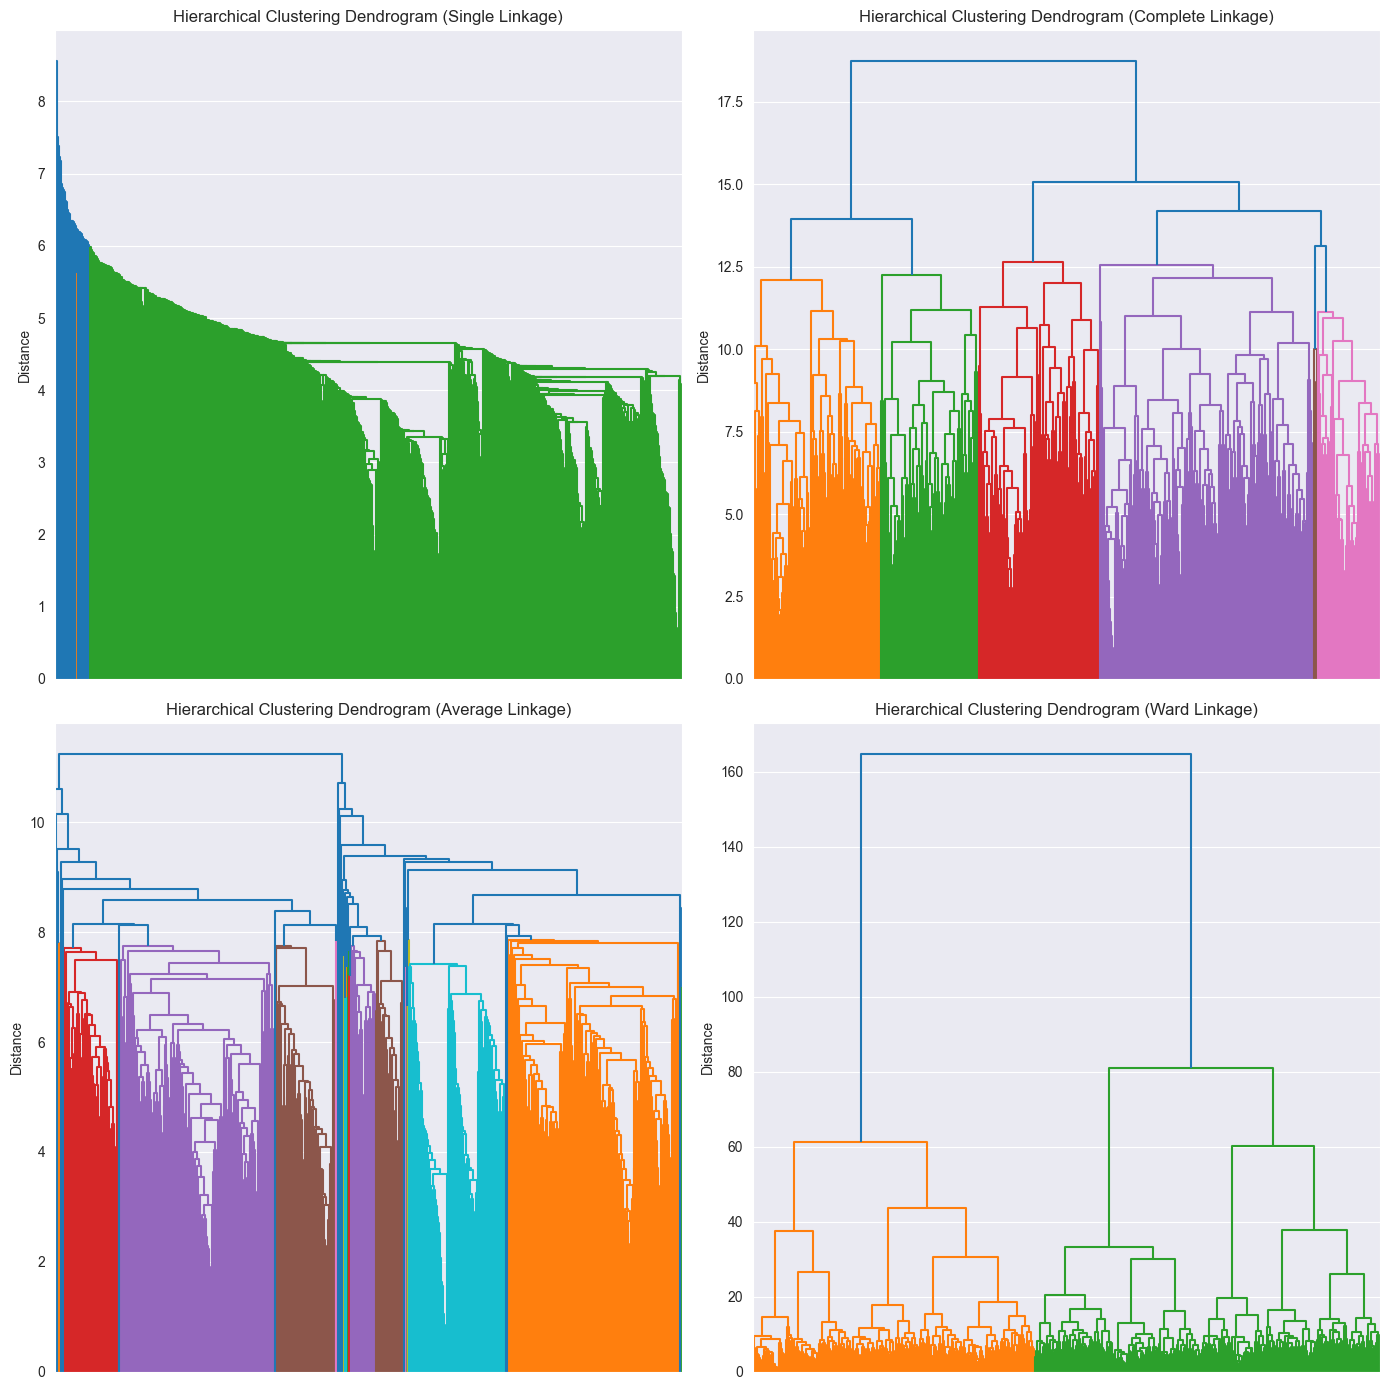

In [80]:
## Hierarchical Clustering (Agglomerative)
# Purpose:
# Explore how candidate responses form clusters step-by-step by successively merging the most similar groups.
# Unlike K-Means, this method does not require choosing the number of clusters in advance.

# We test 4 common linkage methods for hierarchical clustering:
# 1. 'single'   – links clusters based on the **minimum** distance between points.
# 2. 'complete' – links clusters based on the **maximum** distance between points.
# 3. 'average'  – links clusters based on the **average** pairwise distance between all points.
# 4. 'ward'     – merges clusters by minimizing the **increase in total variance** (inertia).

# Step: Prepare figure with 2 rows × 2 columns for 4 dendrograms
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()  # Flatten to easily iterate through subplots

# Method 1: 'single' linkage
linkage_array = linkage(x_Scaled, method='single')
dendrogram(linkage_array, ax=axes[0], no_labels=True)
axes[0].set_title('Hierarchical Clustering Dendrogram (Single Linkage)')
axes[0].set_ylabel('Distance')

# Method 2: 'complete' linkage
linkage_array = linkage(x_Scaled, method='complete')
dendrogram(linkage_array, ax=axes[1], no_labels=True)
axes[1].set_title('Hierarchical Clustering Dendrogram (Complete Linkage)')
axes[1].set_ylabel('Distance')

# Method 3: 'average' linkage
linkage_array = linkage(x_Scaled, method='average')
dendrogram(linkage_array, ax=axes[2], no_labels=True)
axes[2].set_title('Hierarchical Clustering Dendrogram (Average Linkage)')
axes[2].set_ylabel('Distance')

# Method 4: 'ward' linkage (variance-based)
linkage_array = linkage(x_Scaled, method='ward')
dendrogram(linkage_array, ax=axes[3], no_labels=True)
axes[3].set_title('Hierarchical Clustering Dendrogram (Ward Linkage)')
axes[3].set_ylabel('Distance')

# Finalize layout and display all dendrograms
plt.tight_layout()
plt.show()

The generated dendrograms yields the following results:
* Single: Not a useful dendrogram, using min distance does not give a readable result
* Complete: Easily understandable dendrogram, drawing a line at around 13, gives us 5 clusters plus 1 small outlier. This goes well with the k-means results
* Average: Hardly readable dendrogram, hard to read anything useful from this.
* Ward: Placing a line a around 50-70, gives us 3-5 clusters, which also pairs well with the k-means results.

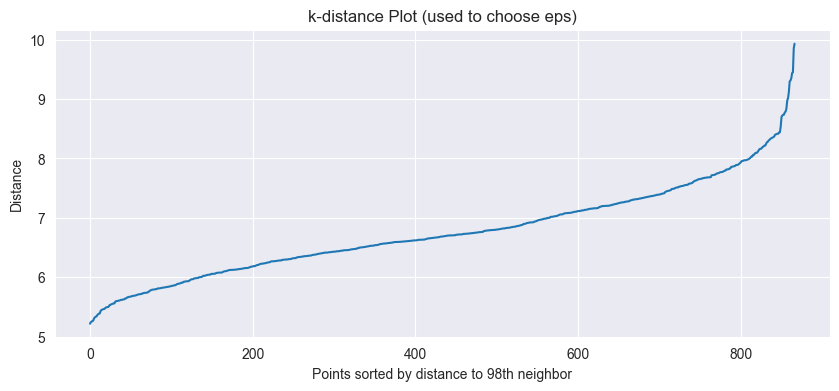

In [81]:
# DBSCAN - k-distance Plot to Choose Epsilon (eps)

# Explanation:
# DBSCAN requires two main parameters:
# - eps: the maximum distance between two samples to be considered neighbors
# - min_samples: the minimum number of points to form a dense region

# A common rule of thumb is to set min_samples = 2 × number of features
# Here, we use min_samples = 98 because we have 49 features

min_samples = 98

# Step 1: Fit NearestNeighbors to find distances to the k-th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(x_Scaled)
distances, indices = neighbors_fit.kneighbors(x_Scaled)

# Step 2: Sort the distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

# Step 3: Plot the sorted k-distances
# The goal is to identify the "elbow point" — a sharp change in slope — as a candidate for eps
plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.title("k-distance Plot (used to choose eps)")
plt.xlabel(f"Points sorted by distance to {min_samples}th neighbor")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

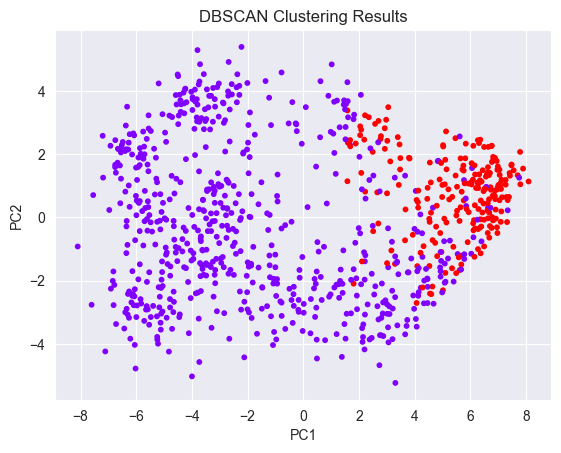

Estimated number of clusters: 1
Number of noise points: 643


In [82]:
# DBSCAN Clustering Based on k-Distance Plot

# Based on the k-distance plot above, we did not observe a sharp elbow,
# but we identified a gradual "shoulder" around eps = 5.5, which is used here.

# Initialize DBSCAN with chosen eps and min_samples
db = DBSCAN(eps=5.5, min_samples=min_samples)
y_dbscan = db.fit_predict(x_Scaled)

# Visualize the clustering result using the PCA projection defined earlier
plotCluster(y_dbscan, "DBSCAN Clustering Results")

# Count the number of identified clusters
# DBSCAN labels noise as -1, so we subtract 1 if -1 is present
n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
print(f"Estimated number of clusters: {n_clusters}")

# Optional: Count the number of points labeled as noise
n_noise = list(y_dbscan).count(-1)
print(f"Number of noise points: {n_noise}")

This gives an unusable result, with 1 cluster and alot of noise points. The reason for this could be that the clusters are not very well separated, which makes sense because politicians can be different even when they're from the same party. I can conclude that Kmeans and hierarchical clustering works better for this dataset.

C:\Users\DooMz\AppData\Local\Temp\ipykernel_22724\2168319633.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parti', y=df[response_cols].std(axis=1), palette=party_colors)


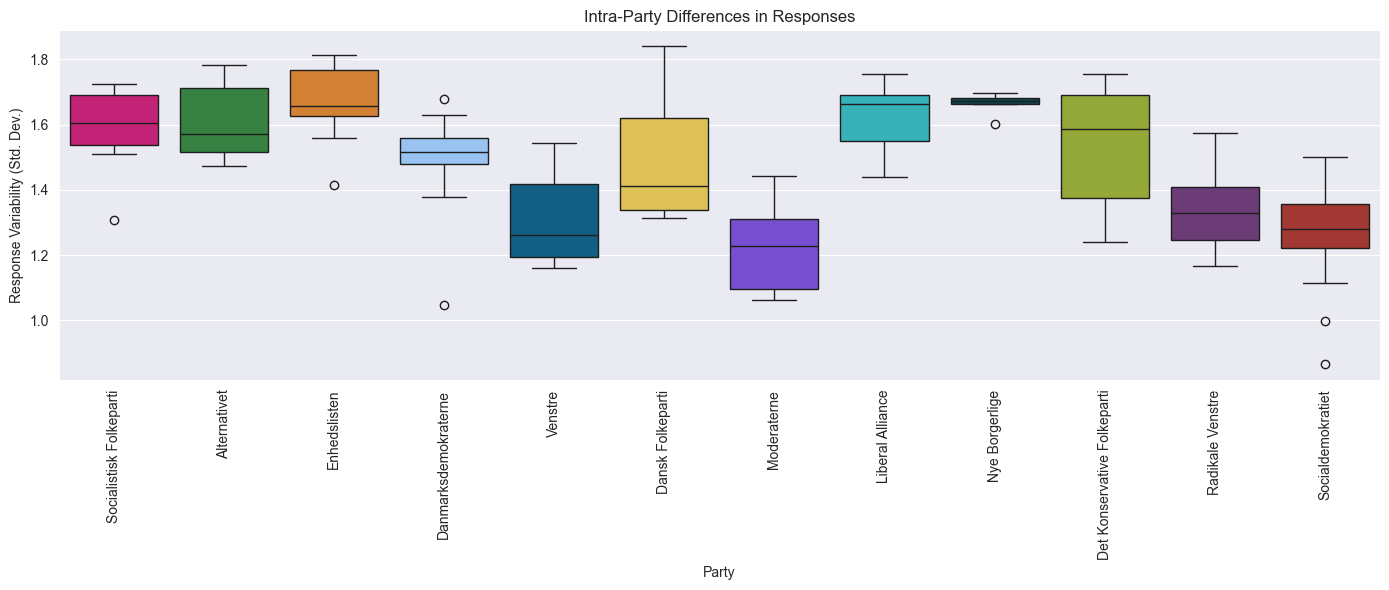

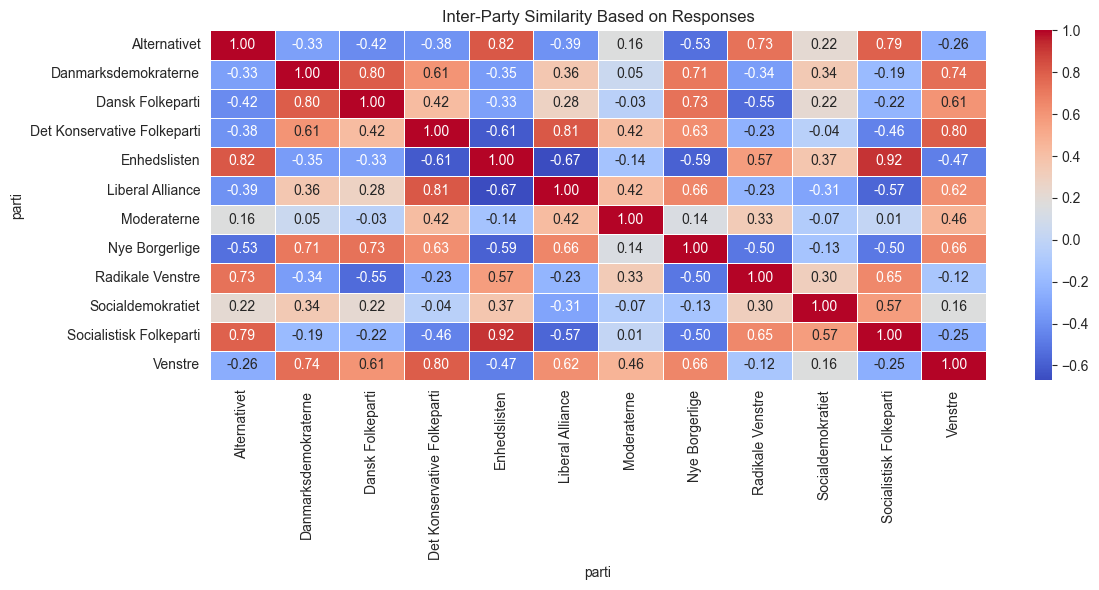

C:\Users\DooMz\AppData\Local\Temp\ipykernel_22724\2168319633.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_variability_df, x='Intra-Party Variability', y='Party', palette=party_colors)


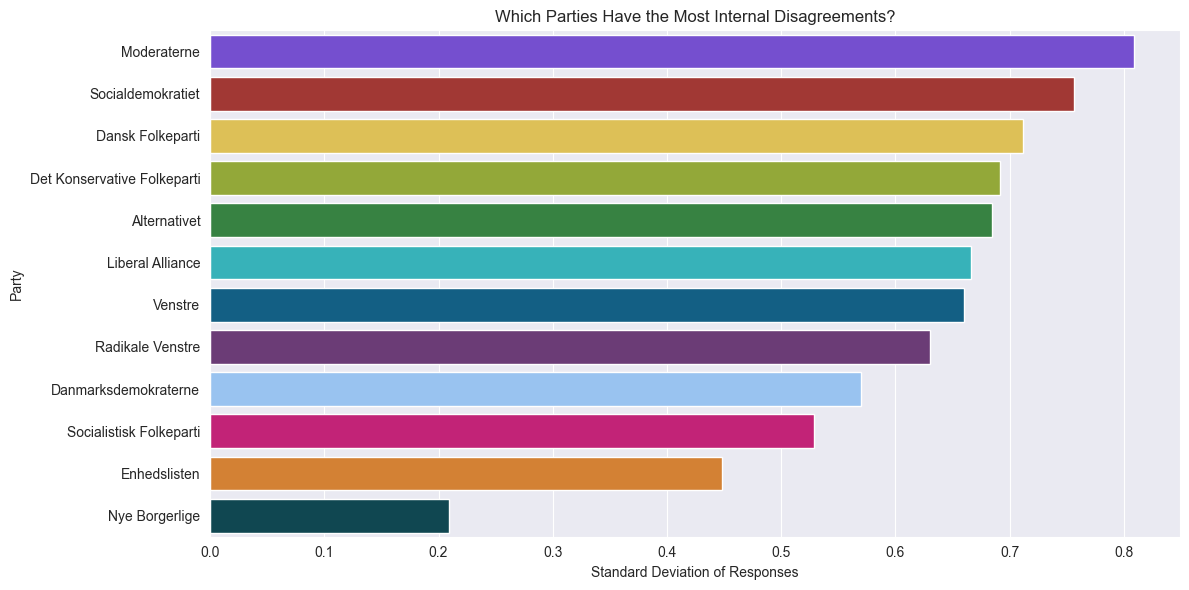


Summary of Internal Disagreements:
                          Party  Intra-Party Variability
6                   Moderaterne                 0.808611
9             Socialdemokratiet                 0.756163
2              Dansk Folkeparti                 0.711759
3   Det Konservative Folkeparti                 0.691127
0                  Alternativet                 0.684217
5              Liberal Alliance                 0.666071
11                      Venstre                 0.659990
8              Radikale Venstre                 0.630073
1          Danmarksdemokraterne                 0.570122
10      Socialistisk Folkeparti                 0.528408
4                  Enhedslisten                 0.448033
7                Nye Borgerlige                 0.208852

Overall inter-party variability (i.e., differences between party means): 1.61


In [83]:
# Overview of the Political Landscape – Elected Candidates
# Goal: Identify agreement and disagreement patterns among parties and their members
# This includes both intra-party (within party) and inter-party (between parties) variability

# Load the dataset
df = pd.read_excel("electeddata.xlsx")

# Step 1: Identify response columns (exclude metadata)
response_cols = df.drop(columns=['navn', 'parti', 'alder'], errors='ignore').select_dtypes(include=['number']).columns

# Step 2: Compute intra-party variability
# This captures the average standard deviation of responses within each party.
# Higher values indicate more internal disagreement.
intra_party_variability = df.groupby('parti')[response_cols].std().mean(axis=1)

# Step 3: Compute inter-party variability
# This calculates how different the average party responses are from each other.
# It's computed as the average variance across all questions using party means.
party_means = df.groupby('parti')[response_cols].mean()
inter_party_variability = party_means.var(axis=0).mean()

# Step 4: Prepare data for plotting internal disagreement by party
party_variability_df = pd.DataFrame({
    'Party': intra_party_variability.index,
    'Intra-Party Variability': intra_party_variability.values
}).sort_values(by='Intra-Party Variability', ascending=False)

# Plot 1: Boxplot showing spread in individual candidate variability within each party
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='parti', y=df[response_cols].std(axis=1), palette=party_colors)
plt.xticks(rotation=90)
plt.xlabel("Party")
plt.ylabel("Response Variability (Std. Dev.)")
plt.title("Intra-Party Differences in Responses")
plt.tight_layout()
plt.show()

# Plot 2: Heatmap showing correlation between average party response profiles
plt.figure(figsize=(12, 6))
sns.heatmap(party_means.T.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Inter-Party Similarity Based on Responses")
plt.tight_layout()
plt.show()

# Plot 3: Bar chart ranking parties by their internal disagreement
plt.figure(figsize=(12, 6))
sns.barplot(data=party_variability_df, x='Intra-Party Variability', y='Party', palette=party_colors)
plt.xlabel("Standard Deviation of Responses")
plt.ylabel("Party")
plt.title("Which Parties Have the Most Internal Disagreements?")
plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary of Internal Disagreements:")
print(party_variability_df)

print(f"\nOverall inter-party variability (i.e., differences between party means): {inter_party_variability:.2f}")

Comments on Intra-party differences:
The boxplot shows the spread of responses within each party. Parties with high variability (Moderaterne, Socialdemokratiet, Dansk folkeparti) indicate internal disagreements among candidates.
Parties with lower variability (Enhedslisten, Nye borgerlige) indicate a more ideological alignment and less disagreements among candidates.

Comments on Inter-party similarity:
The heatmap shows how similar parties are, based on their responses, where dark red indicates high similarity and dark blue suggests opposing positions. 
As for the political accuracy, it is hard for me to comment on, as I am not as politically informed as the task probably requires. I can say that there seems to be a tendency that right-wing parties have higher similarity to other right-wing parties, and the same for left-wing parties being more similar to other left-wing parties, which makes sense, in my head at least.